In [47]:
import pandas as pd
!pip install yfinance

In [48]:
import yfinance as yf

start = "2009-09-25"
end = "2010-02-01"

nike = yf.download("NKE", start=start, end=end)
nike.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NKE,NKE,NKE,NKE,NKE
Date,,,,,
2009-09-25,11.776850,12.019858,11.708566,11.714592,17494400
2009-09-28,11.849153,11.911411,11.740703,11.794928,10106400
2009-09-29,12.068055,12.088138,11.873247,11.895339,34763200
2009-09-30,12.993900,13.044109,12.855327,12.855327,67174800
2009-10-01,12.552063,12.933646,12.552063,12.853312,33036000


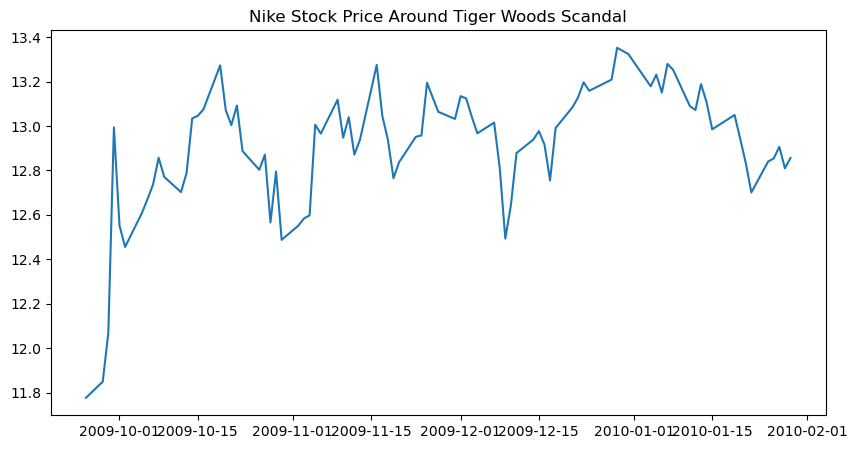

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(nike.index, nike["Close"])
plt.title("Nike Stock Price Around Tiger Woods Scandal")
plt.show()

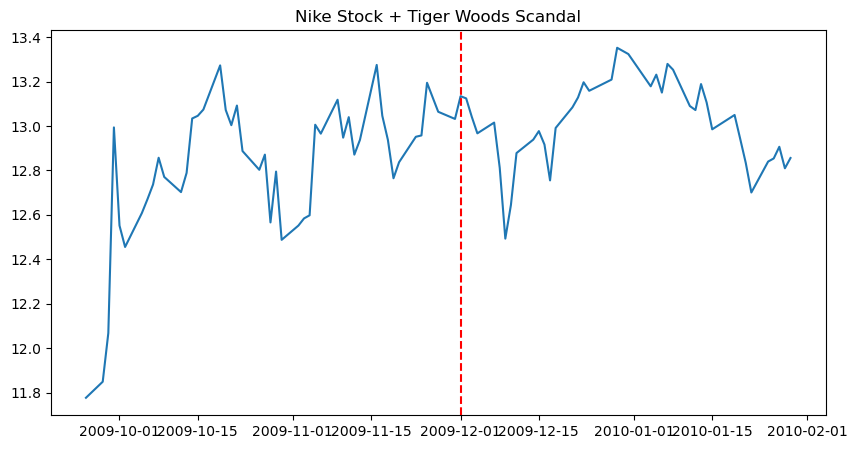

In [50]:
plt.figure(figsize=(10,5))
plt.plot(nike.index, nike["Close"])

plt.axvline(pd.to_datetime("2009-12-01"), color="red", linestyle="--")
plt.title("Nike Stock + Tiger Woods Scandal")
plt.show()

In [51]:
import pandas as pd

df = pd.read_csv("/Users/kaanadaleti/Desktop/dsa_proje/tigerwoods.csv")
df.head()

,Time,Tiger Woods,Nike
0,2009-09-27,2,30
1,2009-10-04,2,29
2,2009-10-11,2,29
3,2009-10-18,1,30
4,2009-10-25,1,29


In [52]:
df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time")

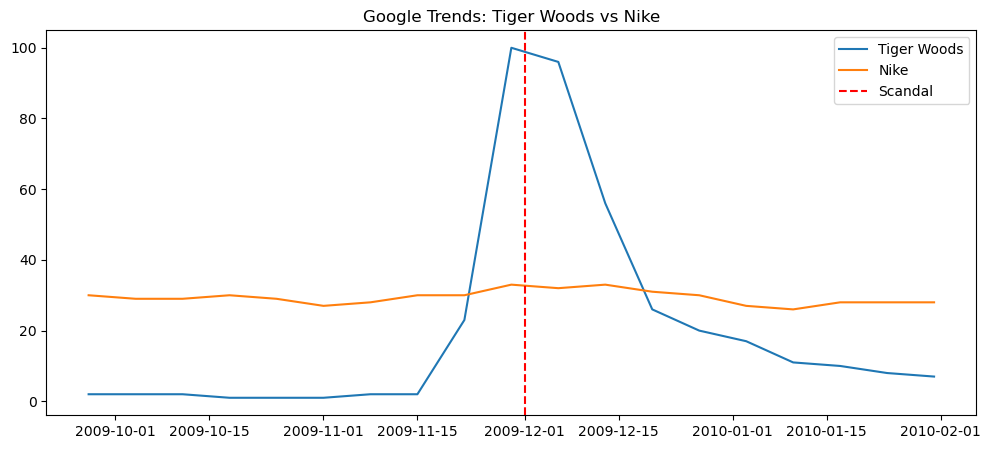

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["Time"], df["Tiger Woods"], label="Tiger Woods")
plt.plot(df["Time"], df["Nike"], label="Nike")

plt.axvline(pd.to_datetime("2009-12-01"), color="red", linestyle="--", label="Scandal")

plt.legend()
plt.title("Google Trends: Tiger Woods vs Nike")
plt.show()

In [54]:
df["TW_norm"] = df["Tiger Woods"] / df["Tiger Woods"].max()
df["Nike_norm"] = df["Nike"] / df["Nike"].max()

In [55]:
df["TW_norm"] = df["Tiger Woods"] / df["Tiger Woods"].max()
nike["Close_norm"] = nike["Close"] / nike["Close"].max()

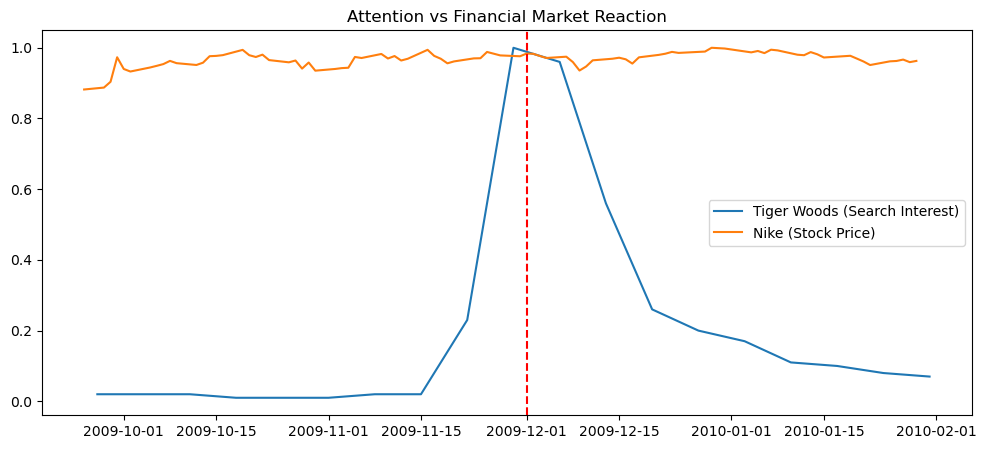

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["Time"], df["TW_norm"], label="Tiger Woods (Search Interest)")
plt.plot(nike.index, nike["Close_norm"], label="Nike (Stock Price)")

plt.axvline(pd.to_datetime("2009-12-01"), color="red", linestyle="--")

plt.legend()
plt.title("Attention vs Financial Market Reaction")
plt.show()

In [57]:
from scipy.stats import ttest_ind

event = pd.to_datetime("2009-12-01")

before = df[df["Time"] < event]["Tiger Woods"]
after = df[df["Time"] >= event]["Tiger Woods"]

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -1.0242408852978926
P-value: 0.3201365190036948


The comparison between search interest and stock market performance highlights the distinction between public attention and financial market response. While search activity captures immediate public awareness, stock prices reflect investor expectations and long-term valuation effects. This separation helps evaluate whether attention shocks translate into economic consequences.